# EV Charging Station Network Optimization
## Optimal Placement and Capacity Allocation of Electric Vehicle Charging Stations
### A Data-Driven Operations Research Decision Support System

**Course:** Operations Research — Group Project
**State:** Ohio (OH)
**Data Sources:**
- NREL/AFDC: `alt_fuel_stations (Aug 19 2026).csv` — real EV charging station locations (2,143 records)
- US Census Bureau ACS 5-Year 2019–2023: `ACSDT5Y2023.B01003-Data.csv` — ZCTA-level population
- US Census Bureau 2023 Gazetteer Files: official ZCTA5 centroid coordinates (`2023_gaz_zcta_oh.csv`)

---

## Pipeline

```
STEP 1  — Data Cleaning              -> Section 2
STEP 2  — Preprocessing / Zone Table -> Section 3
STEP 3  — Exploratory Data Analysis  -> Section 4
STEP 4  — Algorithm 1: MCLP          -> Section 5   (exact MILP + greedy heuristic)
STEP 5  — Algorithm 2: Knapsack      -> Section 6   (charger-mix allocation)
STEP 6  — Evaluation                 -> Section 7
STEP 7  — Results & Interpretation   -> Section 8
STEP 8  — Conclusion                 -> Section 9
STEP 9  — Export for Web Dashboard   -> Section 10
```

## The Two OR Techniques

| Stage | Technique | Question it Answers |
|---|---|---|
| 1 | **MCLP — Integer Programming** (exact, via PuLP/CBC) + **Greedy heuristic** | *Where* to build new stations to cover the most currently-underserved people within budget? |
| 2 | **Knapsack — Integer Programming** | *How many and which type* of chargers at each selected site? |

## Revision notes (this version)

Review 1 flagged an honest limitation in the original pipeline: zone coordinates were
approximated as the **mean location of existing stations per ZIP code**, which meant a ZCTA with
*zero* existing stations had no coordinate at all — so it could never even be considered as a
place to build. 811 of Ohio's 1,215 populated ZCTAs (3.24M people) were silently excluded from
the optimization entirely.

This version fixes that at the root and adds the depth expected for Review 2:

1. **Real ZCTA centroids** from the Census Bureau's official 2023 Gazetteer file replace the
   station-mean approximation — all 1,215 populated Ohio ZCTAs now have coordinates and can be
   demand points *and* candidate build sites.
2. **The optimizer is now existing-infrastructure-aware.** The original MCLP planned new stations
   as if none existed yet, which let it "rediscover" already-served, high-population ZIPs instead
   of prioritizing genuine gaps. Coverage is now defined as *(already covered by an existing
   station) OR (covered by a newly built one)*, so budget is spent on real gaps.
3. **A greedy heuristic is added alongside the exact MILP** — fast enough for an interactive
   dashboard slider, benchmarked against the certified-optimal solution.
4. **Processed outputs are exported** for a FastAPI backend + React dashboard that let a
   non-technical user explore the same model interactively (Section 10).


---
## Section 0 — Setup & File Paths

In [1]:
# ============================================================
# SECTION 0 — SETUP
# Run this first. Install any missing packages with:
#   pip install pulp pandas numpy matplotlib
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pulp
import json
import time
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# ── File paths (relative to this notebook's location: project root) ───────
EV_CSV   = "dataset/alt_fuel_stations (Aug 19 2026).csv"
POP_CSV  = "dataset/ACSDT5Y2023.B01003_2026-08-19T134533/ACSDT5Y2023.B01003-Data.csv"
GAZ_CSV  = "data/external/2023_gaz_zcta_oh.csv"
OUT_DIR  = "data/processed"

# ── State configuration ────────────────────────────────────────────────────
STATE_CODE          = "OH"
STATE_ZCTA_PREFIXES = ("43", "44", "45")   # Ohio ZIP ranges

os.makedirs(OUT_DIR, exist_ok=True)

# ── Verify files exist ─────────────────────────────────────────────────────
for path in [EV_CSV, POP_CSV, GAZ_CSV]:
    exists = os.path.exists(path)
    status = "Found" if exists else "NOT FOUND -- check path / working directory!"
    print(f"{status:24s}: {path}")

print()
print(f"PuLP version  : {pulp.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Setup complete.")


Found                   : dataset/alt_fuel_stations (Aug 19 2026).csv
Found                   : dataset/ACSDT5Y2023.B01003_2026-08-19T134533/ACSDT5Y2023.B01003-Data.csv
Found                   : data/external/2023_gaz_zcta_oh.csv

PuLP version  : 3.3.2
Pandas version: 3.0.5
Setup complete.


---
## Section 1 — Load Raw Data

We load all three files locally — no API calls needed at run time (the Gazetteer file was
downloaded once from census.gov and committed to `data/external/`, see Section 3 note).

**Census population file note:** row 0 holds machine column codes, row 1 holds human-readable
labels (e.g. `"Estimate!!Total"`). We use `skiprows=[1]` to skip that label row.

In [2]:
# -- 1.1  Load EV Stations -------------------------------------------------
stations_raw = pd.read_csv(EV_CSV)

print(f"EV Stations raw shape : {stations_raw.shape}")
print(f"Columns ({len(stations_raw.columns)}): {list(stations_raw.columns[:10])} ...")


EV Stations raw shape : (2143, 75)
Columns (75): ['Fuel Type Code', 'Station Name', 'Street Address', 'Intersection Directions', 'City', 'State', 'ZIP', 'Plus4', 'Station Phone', 'Status Code'] ...


In [3]:
# -- 1.2  Load Census Population --------------------------------------------
census_raw = pd.read_csv(POP_CSV, skiprows=[1])   # skip the human-label row
print(f"Census raw shape : {census_raw.shape}")
print(f"Raw columns      : {list(census_raw.columns)}")
print()
print("First 5 rows:")
display(census_raw.head())


Census raw shape : (33773, 5)
Raw columns      : ['GEO_ID', 'NAME', 'B01003_001E', 'B01003_001M', 'Unnamed: 4']

First 5 rows:


,GEO_ID,NAME,B01003_001E,B01003_001M,Unnamed: 4
0,0400000US39,Ohio,11780046,*****,NaN
1,860Z200US00601,ZCTA5 00601,16721,477,NaN
2,860Z200US00602,ZCTA5 00602,37510,263,NaN
3,860Z200US00603,ZCTA5 00603,48317,1021,NaN
4,860Z200US00606,ZCTA5 00606,5435,331,NaN


In [4]:
# -- 1.3  Load Census Gazetteer (official ZCTA centroids, Ohio only) --------
gaz_raw = pd.read_csv(GAZ_CSV, dtype={'zcta': str})
print(f"Gazetteer raw shape (Ohio ZCTAs): {gaz_raw.shape}")
display(gaz_raw.head())


Gazetteer raw shape (Ohio ZCTAs): (1233, 3)


,zcta,latitude,longitude
0,43001,40.09,-82.61
1,43002,40.06,-83.17
2,43003,40.41,-82.97
3,43004,40.02,-82.80
4,43005,40.28,-82.27


In [5]:
# -- 1.4  Quick raw inspection: EV Stations ----------------------------------
print("=== RAW EV STATIONS SNAPSHOT ===")
print(f"Total rows           : {len(stations_raw):,}")
print(f"State breakdown      : {stations_raw['State'].value_counts().to_dict()}")
print(f"Fuel type            : {stations_raw['Fuel Type Code'].value_counts().to_dict()}")
print(f"Access Code          : {stations_raw['Access Code'].value_counts().to_dict()}")
print(f"Status Code          : {stations_raw['Status Code'].value_counts().to_dict()}")
print()
print("Missing values in key columns:")
key_cols = ['Latitude','Longitude','ZIP',
            'EV Level1 EVSE Num','EV Level2 EVSE Num','EV DC Fast Count']
print(stations_raw[key_cols].isnull().sum().to_string())


=== RAW EV STATIONS SNAPSHOT ===
Total rows           : 2,143
State breakdown      : {'OH': 2143}
Fuel type            : {'ELEC': 2143}
Access Code          : {'public': 1967, 'private': 176}
Status Code          : {'E': 2069, 'T': 50, 'P': 24}

Missing values in key columns:
Latitude                 0
Longitude                0
ZIP                      0
EV Level1 EVSE Num    2133
EV Level2 EVSE Num     420
EV DC Fast Count      1691


In [6]:
# -- 1.5  Quick raw inspection: Census ---------------------------------------
print("=== RAW CENSUS SNAPSHOT ===")
print(f"Total rows (national): {len(census_raw):,}")
zcta_rows = census_raw[census_raw['GEO_ID'].str.contains('860Z', na=False)]
print(f"ZCTA rows nationally : {len(zcta_rows):,}")
print(f"State row (Ohio)     : {len(census_raw[census_raw['GEO_ID']=='0400000US39'])} row(s)")


=== RAW CENSUS SNAPSHOT ===
Total rows (national): 33,773
ZCTA rows nationally : 33,772
State row (Ohio)     : 1 row(s)


---
## Section 2 — Data Cleaning (STEP 1)

### What we clean and WHY

**EV Stations:**
| Action | Why |
|--------|-----|
| Drop rows with missing GPS coordinates | Can't locate/map a station without lat/lon |
| Keep only `Access Code == 'public'` | Private stations don't serve the general public |
| Keep only `Status Code == 'E'` (Open) | Planned/temporarily-closed stations don't exist yet |
| Fill missing charger counts with 0 | NaN means no charger of that type, not unknown |
| Drop exact duplicate entries | Same station entered twice — corrupts counts |
| Standardize column names to lowercase + underscores | Consistent key referencing downstream |

**Population:**
| Action | Why |
|--------|-----|
| Keep only ZCTA rows (skip state/national) | We need ZIP-level data, not state aggregates |
| Extract 5-digit ZCTA from `NAME` column | Join key must be a clean 5-digit string |
| Filter to Ohio ZCTAs (prefix 43/44/45) | We're optimizing for Ohio only |
| Drop zero-population ZCTAs | Nobody lives there — irrelevant demand zones |
| Convert population to numeric | Stored as string in the raw CSV |

**Gazetteer:** kept as-is (already Ohio-only, already numeric lat/lon) — just typed and renamed.

In [7]:
# -- 2.1  Clean EV Stations ---------------------------------------------------

def clean_station_data(df):
    """
    Full cleaning pipeline for NREL/AFDC EV station data.
    Returns cleaned DataFrame with standardized column names.
    """
    df = df.copy()
    start = len(df)
    print(f"  Starting rows: {start:,}")

    df.columns = [
        c.lower().replace(' ', '_').replace('-', '_')
                  .replace('(', '').replace(')', '').replace('/', '_')
        for c in df.columns
    ]

    df = df.dropna(subset=['latitude', 'longitude'])
    print(f"  After drop missing GPS      : {len(df):,}  (dropped {start - len(df):,})")

    n_before = len(df)
    if 'access_code' in df.columns:
        df = df[df['access_code'].str.lower() == 'public']
    print(f"  After keep public only      : {len(df):,}  (dropped {n_before - len(df):,} private)")

    n_before = len(df)
    if 'status_code' in df.columns:
        df = df[df['status_code'].str.upper() == 'E']
    print(f"  After keep status=E only    : {len(df):,}  (dropped {n_before - len(df):,} non-open)")

    charger_cols = ['ev_level1_evse_num', 'ev_level2_evse_num', 'ev_dc_fast_count']
    for col in charger_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    n_before = len(df)
    dedup_cols = [c for c in ['latitude', 'longitude', 'station_name'] if c in df.columns]
    if dedup_cols:
        df = df.drop_duplicates(subset=dedup_cols)
    print(f"  After drop duplicates       : {len(df):,}  (dropped {n_before - len(df):,} dupes)")

    df['zip'] = df['zip'].astype(str).str.extract(r'(\d{5})')[0]

    df = df.reset_index(drop=True)
    print(f"  Clean stations final count: {len(df):,}")
    return df


print("=== Cleaning EV Station Data ===")
stations_clean = clean_station_data(stations_raw)
print()
display(stations_clean[['station_name','city','state','zip',
                         'access_code','status_code',
                         'latitude','longitude',
                         'ev_level2_evse_num','ev_dc_fast_count']].head(5))


=== Cleaning EV Station Data ===
  Starting rows: 2,143
  After drop missing GPS      : 2,143  (dropped 0)
  After keep public only      : 1,967  (dropped 176 private)
  After keep status=E only    : 1,917  (dropped 50 non-open)
  After drop duplicates       : 1,916  (dropped 1 dupes)
  Clean stations final count: 1,916



,station_name,city,state,zip,access_code,status_code,latitude,longitude,ev_level2_evse_num,ev_dc_fast_count
0,Baker Electric Building,Cleveland,OH,44103,public,E,41.50,-81.64,1.00,0.00
1,Ohio Statehouse Parking Garage,Columbus,OH,43215,public,E,39.96,-83.00,8.00,0.00
2,Thayer Nissan,Bowling Green,OH,43402,public,E,41.42,-83.65,1.00,0.00
3,Busam Motor Sales,Cincinnati,OH,45246,public,E,39.29,-84.45,1.00,0.00
4,Jeff Wyler Nissan - Cincinnati,Cincinnati,OH,45251,public,E,39.23,-84.59,1.00,0.00


In [8]:
# -- 2.2  Clean Census Population Data ---------------------------------------

def clean_population_data(df, state_zcta_prefixes):
    """
    Cleans the US Census ACS 5-Year population data down to Ohio ZCTAs.

    GEO_ID patterns:
      '0400000US39'     = Ohio state-level (skip)
      '860Z200US43001'  = ZCTA5 43001 (keep)
    """
    df = df.copy()
    print(f"  Starting rows (national): {len(df):,}")

    df.columns = ['GEO_ID', 'NAME', 'population', 'margin_of_error'] + [
        f'extra_{i}' for i in range(len(df.columns) - 4)
    ]

    n_before = len(df)
    df = df[df['GEO_ID'].str.contains('860Z', na=False)].copy()
    print(f"  After keep ZCTA rows only   : {len(df):,}  (dropped {n_before - len(df):,} non-ZCTA)")

    df['zcta'] = df['NAME'].str.extract(r'ZCTA5 (\d{5})')
    df = df.dropna(subset=['zcta'])

    df['population'] = pd.to_numeric(df['population'], errors='coerce')
    df = df.dropna(subset=['population'])
    df['population'] = df['population'].astype(int)

    n_before = len(df)
    df = df[df['zcta'].str.startswith(tuple(state_zcta_prefixes))]
    print(f"  After filter to {state_zcta_prefixes}: {len(df):,}  (dropped {n_before - len(df):,} other states)")

    n_before = len(df)
    df = df[df['population'] > 0]
    print(f"  After drop zero-population  : {len(df):,}  (dropped {n_before - len(df):,} empty ZCTAs)")

    df = df[['zcta', 'population']].reset_index(drop=True)
    print(f"  Clean population final count: {len(df):,} Ohio ZCTAs")
    return df


print("=== Cleaning Census Population Data ===")
population_clean = clean_population_data(census_raw, STATE_ZCTA_PREFIXES)
display(population_clean.head(10))


=== Cleaning Census Population Data ===
  Starting rows (national): 33,773
  After keep ZCTA rows only   : 33,772  (dropped 1 non-ZCTA)
  After filter to ('43', '44', '45'): 1,233  (dropped 32,539 other states)
  After drop zero-population  : 1,215  (dropped 18 empty ZCTAs)
  Clean population final count: 1,215 Ohio ZCTAs


,zcta,population
0,43001,2639
1,43002,711
2,43003,3376
3,43004,31416
4,43005,308
5,43006,521
6,43007,34
7,43008,2419
8,43009,2054
9,43010,280


In [9]:
# -- 2.3  Clean Gazetteer (official ZCTA centroids) --------------------------
gazetteer_clean = gaz_raw.copy()
gazetteer_clean['zcta'] = gazetteer_clean['zcta'].astype(str).str.zfill(5)
gazetteer_clean['latitude'] = pd.to_numeric(gazetteer_clean['latitude'], errors='coerce')
gazetteer_clean['longitude'] = pd.to_numeric(gazetteer_clean['longitude'], errors='coerce')
gazetteer_clean = gazetteer_clean.dropna()

print(f"Clean gazetteer: {len(gazetteer_clean):,} Ohio ZCTA centroids")
print("Source: US Census Bureau, 2023 Gazetteer Files (ZCTA5 national), filtered to prefixes "
      f"{STATE_ZCTA_PREFIXES}. These are the Bureau's own internal-point coordinates for every "
      "ZCTA polygon -- not an approximation.")
display(gazetteer_clean.head())


Clean gazetteer: 1,233 Ohio ZCTA centroids
Source: US Census Bureau, 2023 Gazetteer Files (ZCTA5 national), filtered to prefixes ('43', '44', '45'). These are the Bureau's own internal-point coordinates for every ZCTA polygon -- not an approximation.


,zcta,latitude,longitude
0,43001,40.09,-82.61
1,43002,40.06,-83.17
2,43003,40.41,-82.97
3,43004,40.02,-82.80
4,43005,40.28,-82.27


In [10]:
# -- 2.4  Cleaning Summary ----------------------------------------------------
print("+" + "="*60 + "+")
print("|            STEP 1 -- DATA CLEANING SUMMARY               |")
print("+" + "="*60 + "+")
print(f"  EV Stations raw          : {len(stations_raw):>6,} rows")
print(f"  EV Stations after clean  : {len(stations_clean):>6,} rows")
print(f"  Population (national)    : {len(census_raw):>6,} rows")
print(f"  Population (Ohio ZCTAs)  : {len(population_clean):>6,} rows")
print(f"  Gazetteer (Ohio ZCTAs)   : {len(gazetteer_clean):>6,} rows")
print(f"  Total Ohio population    : {population_clean['population'].sum():>10,}")


+============================================================+
|            STEP 1 -- DATA CLEANING SUMMARY               |
+============================================================+
  EV Stations raw          :  2,143 rows
  EV Stations after clean  :  1,916 rows
  Population (national)    : 33,773 rows
  Population (Ohio ZCTAs)  :  1,215 rows
  Gazetteer (Ohio ZCTAs)   :  1,233 rows
  Total Ohio population    : 11,780,046


---
## Section 3 — Preprocessing (STEP 2)

### Goal
Build a single **zone table** — one row per *populated* Ohio ZCTA — with:
```
zcta | latitude | longitude | population | existing_stations | existing_level2 | existing_dcfc | dist_to_nearest_station_km
```

### What changed from the Review-1 version
The original approach used the **mean coordinate of existing stations within a ZCTA** as that
zone's centroid. That only works for ZCTAs that already have a station — 811 of Ohio's 1,215
populated ZCTAs (3.24M people) had no station and therefore no coordinate, so they were dropped
from the zone table entirely and could never be *chosen* as a new site.

**Fix:** join population directly to the Census Bureau's own **Gazetteer internal-point
coordinates** (`data/external/2023_gaz_zcta_oh.csv`, downloaded once from
`www2.census.gov/geo/docs/maps-data/data/gazetteer/2023_Gazetteer/`). Every populated ZCTA gets a
real, official centroid regardless of whether it currently has a station. Station counts are then
left-joined on top (0 if none) — a ZCTA with zero stations is no longer *invisible*, it's a
first-class candidate site with real coordinates.

We also compute, per zone, the **straight-line distance to the nearest existing station** — this
is what lets us later ask "is this zone already covered by the existing network?" using the same
distance-based definition as the optimizer, rather than the coarser "does this ZIP code contain a
station" flag.

In [11]:
# -- 3.1  Build Zone Table (population-driven, real centroids) --------------

def build_zone_table(population_df, gazetteer_df, stations_df):
    """
    One row per Ohio ZCTA with population > 0.

    latitude / longitude   : OFFICIAL Census Gazetteer centroid (not approximated)
    existing_stations      : count of public, open stations physically in that ZIP
    existing_level1/2/dcfc : sum of charger ports of each type in that ZIP
    (all default to 0 when a ZCTA currently has no station -- it still gets a row)
    """
    zones = population_df.merge(gazetteer_df, on='zcta', how='inner')
    print(f"  Population ZCTAs            : {len(population_df):,}")
    print(f"  After join with gazetteer   : {len(zones):,}  "
          f"(unmatched: {len(population_df) - len(zones)})")

    agg = stations_df.groupby('zip').agg(
        existing_stations=('station_name', 'count'),
        existing_level1=('ev_level1_evse_num', 'sum'),
        existing_level2=('ev_level2_evse_num', 'sum'),
        existing_dcfc=('ev_dc_fast_count', 'sum'),
    ).reset_index().rename(columns={'zip': 'zcta'})

    zones = zones.merge(agg, on='zcta', how='left')
    for c in ['existing_stations', 'existing_level1', 'existing_level2', 'existing_dcfc']:
        zones[c] = zones[c].fillna(0).astype(int)

    zones = zones.sort_values('zcta').reset_index(drop=True)
    print(f"  Final zone table             : {len(zones):,} zones "
          f"({(zones['existing_stations']>0).sum()} with >=1 station, "
          f"{(zones['existing_stations']==0).sum()} with zero -- these are now INCLUDED)")
    return zones


print("=== Building Zone Table ===")
zones = build_zone_table(population_clean, gazetteer_clean, stations_clean)
display(zones.head(10))


=== Building Zone Table ===
  Population ZCTAs            : 1,215
  After join with gazetteer   : 1,215  (unmatched: 0)
  Final zone table             : 1,215 zones (404 with >=1 station, 811 with zero -- these are now INCLUDED)


,zcta,population,latitude,longitude,existing_stations,existing_level1,existing_level2,existing_dcfc
0,43001,2639,40.09,-82.61,0,0,0,0
1,43002,711,40.06,-83.17,0,0,0,0
2,43003,3376,40.41,-82.97,0,0,0,0
3,43004,31416,40.02,-82.80,1,0,1,0
4,43005,308,40.28,-82.27,0,0,0,0
5,43006,521,40.46,-82.15,0,0,0,0
6,43007,34,40.33,-83.40,0,0,0,0
7,43008,2419,39.93,-82.48,0,0,0,0
8,43009,2054,40.17,-83.64,0,0,0,0
9,43010,280,40.00,-83.62,0,0,0,0


In [12]:
# -- 3.2  Distance to nearest EXISTING station (per zone) -------------------
# Straight-line (Haversine) distance in km. Used to define "already covered by
# the existing network" using the same yardstick the optimizer will use later.

def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized great-circle distance (km) between one point and arrays of points."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


station_lat = stations_clean['latitude'].values
station_lon = stations_clean['longitude'].values

t0 = time.time()
zones['dist_to_nearest_station_km'] = [
    haversine_km(zlat, zlon, station_lat, station_lon).min()
    for zlat, zlon in zip(zones['latitude'], zones['longitude'])
]
print(f"Computed nearest-station distance for {len(zones)} zones in {time.time()-t0:.2f}s")
print()
print(zones[['zcta','population','existing_stations','dist_to_nearest_station_km']]
      .sort_values('dist_to_nearest_station_km', ascending=False).head(10))


Computed nearest-station distance for 1215 zones in 0.05s

       zcta  population  existing_stations  dist_to_nearest_station_km
387   43946        1501                  0                       46.08
375   43931         132                  0                       44.33
368   43915        1305                  0                       36.25
339   43793        4879                  0                       35.04
1100  45734         301                  0                       30.41
823   45101        1876                  0                       29.94
855   45156          50                  0                       29.61
862   45167        3379                  0                       29.56
830   45112          14                  0                       29.39
1115  45767        2566                  0                       29.36


In [13]:
# -- 3.3  Build zone-to-zone Distance Matrix ---------------------------------
# Full n x n great-circle distance matrix between every pair of zone centroids.
# Used by the MCLP to determine which zones a candidate build site can cover.

def build_distance_matrix(zones_df):
    """Fully vectorized n x n Haversine distance matrix (km)."""
    R = 6371.0
    lat = np.radians(zones_df['latitude'].values)[:, None]
    lon = np.radians(zones_df['longitude'].values)[:, None]
    dlat = lat - lat.T
    dlon = lon - lon.T
    a = np.sin(dlat/2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


print("Building zone-to-zone distance matrix...")
t0 = time.time()
distance_matrix = build_distance_matrix(zones)
print(f"Distance matrix shape: {distance_matrix.shape}  (built in {time.time()-t0:.2f}s)")

off_diag = distance_matrix[distance_matrix > 0]
nn_dist = distance_matrix.copy()
np.fill_diagonal(nn_dist, np.inf)
nearest_neighbor = nn_dist.min(axis=1)

print()
print("Distance statistics across ALL zone pairs (not just neighbors):")
print(f"  Mean  : {off_diag.mean():.2f} km   Median: {np.median(off_diag):.2f} km   Max: {off_diag.max():.2f} km")
print()
print("Nearest-NEIGHBOR distance (each zone to its closest other zone) -- what actually")
print("matters for picking a sensible coverage radius:")
print(f"  Mean  : {nearest_neighbor.mean():.2f} km")
print(f"  Median: {np.median(nearest_neighbor):.2f} km")
print(f"  90th percentile: {np.percentile(nearest_neighbor, 90):.2f} km")
print()
print("Symmetry check (should be ~0):", f"{np.abs(distance_matrix - distance_matrix.T).max():.6f} km")


Building zone-to-zone distance matrix...


Distance matrix shape: (1215, 1215)  (built in 0.03s)

Distance statistics across ALL zone pairs (not just neighbors):
  Mean  : 179.63 km   Median: 176.11 km   Max: 469.02 km

Nearest-NEIGHBOR distance (each zone to its closest other zone) -- what actually
matters for picking a sensible coverage radius:
  Mean  : 6.18 km
  Median: 6.07 km
  90th percentile: 10.02 km

Symmetry check (should be ~0): 0.000000 km


In [14]:
# -- 3.4  Coverage Radius Selection ------------------------------------------
# A station at candidate zone i covers demand zone j if distance(i, j) <= r.
# We sweep r against ALREADY-EXISTING infrastructure to see how much of Ohio's
# population currently has access at each radius, and pick a realistic default.

radius_sweep = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
pop_arr = zones['population'].values
dist_arr = zones['dist_to_nearest_station_km'].values

sweep_rows = []
for r in radius_sweep:
    covered = dist_arr <= r
    sweep_rows.append({
        'radius_km': r,
        'zones_covered': int(covered.sum()),
        'pct_zones_covered': round(100*covered.sum()/len(zones), 1),
        'population_covered': int(pop_arr[covered].sum()),
        'pct_population_covered': round(100*pop_arr[covered].sum()/pop_arr.sum(), 1),
    })
radius_sweep_df = pd.DataFrame(sweep_rows)
print("=== Existing-network coverage at candidate service radii ===")
display(radius_sweep_df)

# RADIUS_KM = 5 km (~3 miles): a realistic "close to home / short drive" charging
# radius -- covers 78.6% of the population today, leaving a genuine, presentable
# gap for the optimizer to target (not saturated, not empty).
RADIUS_KM = 5

print(f"\nSelected RADIUS_KM = {RADIUS_KM} km  "
      f"(~{RADIUS_KM/1.609:.1f} miles) for the remainder of this notebook.")
print(f"Rationale: median nearest-neighbor spacing between Ohio ZCTAs is "
      f"{np.median(nearest_neighbor):.1f} km, and {RADIUS_KM} km already covers "
      f"{radius_sweep_df.loc[radius_sweep_df.radius_km==RADIUS_KM, 'pct_population_covered'].iloc[0]}% "
      f"of the population today -- large enough to be realistic, small enough that a "
      f"meaningful, honest coverage gap remains to optimize against.")


=== Existing-network coverage at candidate service radii ===


,radius_km,zones_covered,pct_zones_covered,population_covered,pct_population_covered
0,2,251,20.70,5175032,43.90
1,3,353,29.10,7165345,60.80
2,4,429,35.30,8482755,72.00
3,5,500,41.20,9264909,78.60
4,6,543,44.70,9554293,81.10
5,8,626,51.50,9955310,84.50
6,10,730,60.10,10402276,88.30
7,12,847,69.70,10830735,91.90
8,15,1003,82.60,11272178,95.70
9,20,1131,93.10,11566775,98.20



Selected RADIUS_KM = 5 km  (~3.1 miles) for the remainder of this notebook.
Rationale: median nearest-neighbor spacing between Ohio ZCTAs is 6.1 km, and 5 km already covers 78.6% of the population today -- large enough to be realistic, small enough that a meaningful, honest coverage gap remains to optimize against.


In [15]:
# -- 3.5  Baseline Existing Coverage (at RADIUS_KM) --------------------------
# This is the "before optimization" reality check: given what's already built,
# how much of Ohio is covered right now? Everything the MCLP does in Section 5
# is measured as an IMPROVEMENT over this baseline, not from a blank slate.

zones['covered_by_existing'] = zones['dist_to_nearest_station_km'] <= RADIUS_KM

baseline_covered_pop = int(zones.loc[zones['covered_by_existing'], 'population'].sum())
baseline_total_pop   = int(zones['population'].sum())
baseline_pct         = round(100 * baseline_covered_pop / baseline_total_pop, 1)
baseline_gap_pop     = baseline_total_pop - baseline_covered_pop
baseline_gap_zones   = zones.loc[~zones['covered_by_existing']]

print("=== BASELINE: Existing Network Coverage (before any new stations) ===")
print(f"  Coverage radius              : {RADIUS_KM} km")
print(f"  Zones already covered        : {int(zones['covered_by_existing'].sum())} / {len(zones)}")
print(f"  Population already covered   : {baseline_covered_pop:,} ({baseline_pct}%)")
print(f"  Population still uncovered   : {baseline_gap_pop:,} ({100-baseline_pct:.1f}%)")
print(f"  Uncovered zones              : {len(baseline_gap_zones)}")


=== BASELINE: Existing Network Coverage (before any new stations) ===
  Coverage radius              : 5 km
  Zones already covered        : 500 / 1215
  Population already covered   : 9,264,909 (78.6%)
  Population still uncovered   : 2,515,137 (21.4%)
  Uncovered zones              : 715


In [16]:
# -- 3.6  Top Gap Zones (underserved, high population) -----------------------
gap_zones = zones[zones['existing_stations'] == 0].sort_values('population', ascending=False)

print(f"=== Top 15 Coverage Gap Zones (population, ZERO EV stations physically in the ZIP) ===")
print("These now have REAL coordinates (Gazetteer) and can be selected by the optimizer.")
display(gap_zones[['zcta','population','dist_to_nearest_station_km','covered_by_existing']]
        .head(15).reset_index(drop=True))


=== Top 15 Coverage Gap Zones (population, ZERO EV stations physically in the ZIP) ===
These now have REAL coordinates (Gazetteer) and can be selected by the optimizer.


,zcta,population,dist_to_nearest_station_km,covered_by_existing
0,44111,39950,1.64,True
1,44203,38705,6.59,False
2,45503,32673,6.20,False
3,44266,32301,11.81,False
4,44004,31076,9.20,False
5,43119,29423,5.19,False
6,43614,29396,2.00,True
7,45244,28720,4.78,True
8,45042,28217,5.73,False
9,44052,28067,5.61,False


---
## Section 4 — Exploratory Data Analysis (STEP 3)

This section answers five questions before any optimization runs:
1. How is population distributed across Ohio ZIP zones?
2. Which zones have the most people but the fewest stations (underserved)?
3. Where are the geographic coverage gaps — now that gap zones have real coordinates?
4. What does existing charging infrastructure look like spatially?
5. How sensitive is "coverage" to the radius we choose?

In [17]:
# -- 4.1  Summary Statistics --------------------------------------------------
total_pop   = zones['population'].sum()
total_stations = int(zones['existing_stations'].sum())
total_l2    = int(zones['existing_level2'].sum())
total_dcfc  = int(zones['existing_dcfc'].sum())
n_gap_zones = int((zones['existing_stations'] == 0).sum())
gap_pop     = int(zones.loc[zones['existing_stations']==0, 'population'].sum())

print("+" + "="*64 + "+")
print("|         STEP 3 -- EXPLORATORY DATA ANALYSIS SUMMARY          |")
print("+" + "="*64 + "+")
print(f"  State analyzed                 : Ohio (OH)")
print(f"  Total Ohio population (ACS)    : {total_pop:>12,}")
print(f"  Total populated ZCTAs          : {len(zones):>6,}")
print(f"  ZCTAs with >=1 station         : {len(zones)-n_gap_zones:>6,}")
print(f"  ZCTAs with ZERO stations       : {n_gap_zones:>6,}  ({gap_pop:,} people, {100*gap_pop/total_pop:.1f}%)")
print(f"  Total public open EV stations  : {total_stations:>6,}")
print(f"  Total Level 2 charging ports   : {total_l2:>6,}")
print(f"  Total DC Fast charging ports   : {total_dcfc:>6,}")
print(f"  Population covered @ {RADIUS_KM}km baseline : {baseline_pct}%  ({baseline_covered_pop:,} people)")
print("+" + "="*64 + "+")


+================================================================+
|         STEP 3 -- EXPLORATORY DATA ANALYSIS SUMMARY          |
+================================================================+
  State analyzed                 : Ohio (OH)
  Total Ohio population (ACS)    :   11,780,046
  Total populated ZCTAs          :  1,215
  ZCTAs with >=1 station         :    404
  ZCTAs with ZERO stations       :    811  (3,240,333 people, 27.5%)
  Total public open EV stations  :  1,909
  Total Level 2 charging ports   :  3,746
  Total DC Fast charging ports   :  1,508
  Population covered @ 5km baseline : 78.6%  (9,264,909 people)
+================================================================+


In [18]:
# -- 4.2  Top / Bottom Zones --------------------------------------------------
print("=== Top 10 Most Populous Zones (highest demand priority) ===")
top_pop = zones.nlargest(10, 'population')[['zcta','population','existing_stations','dist_to_nearest_station_km']]
top_pop['stations_per_10k'] = (top_pop['existing_stations'] / top_pop['population'] * 10_000).round(2)
display(top_pop.reset_index(drop=True))

print()
print("=== Top 10 Underserved Zones (pop > 20k, fewest stations, farthest from existing network) ===")
underserved = zones[zones['population'] > 20_000].sort_values(
    ['covered_by_existing', 'existing_stations', 'population'], ascending=[True, True, False]
)[['zcta','population','existing_stations','dist_to_nearest_station_km','covered_by_existing']]
display(underserved.head(10).reset_index(drop=True))


=== Top 10 Most Populous Zones (highest demand priority) ===


,zcta,population,existing_stations,dist_to_nearest_station_km,stations_per_10k
0,45011,74636,10,4.56,1.34
1,43123,66366,13,2.46,1.96
2,43026,64644,10,2.15,1.55
3,44256,64606,6,0.53,0.93
4,43081,64314,13,3.27,2.02
5,43055,62697,12,4.08,1.91
6,43130,62450,10,2.07,1.60
7,44035,62024,11,2.34,1.77
8,44060,60257,16,0.96,2.66
9,43230,59522,9,3.03,1.51



=== Top 10 Underserved Zones (pop > 20k, fewest stations, farthest from existing network) ===


,zcta,population,existing_stations,dist_to_nearest_station_km,covered_by_existing
0,44203,38705,0,6.59,False
1,45503,32673,0,6.20,False
2,44266,32301,0,11.81,False
3,44004,31076,0,9.20,False
4,43119,29423,0,5.19,False
5,45042,28217,0,5.73,False
6,44052,28067,0,5.61,False
7,45102,24838,0,8.62,False
8,45030,21328,0,11.42,False
9,45322,20978,0,5.22,False


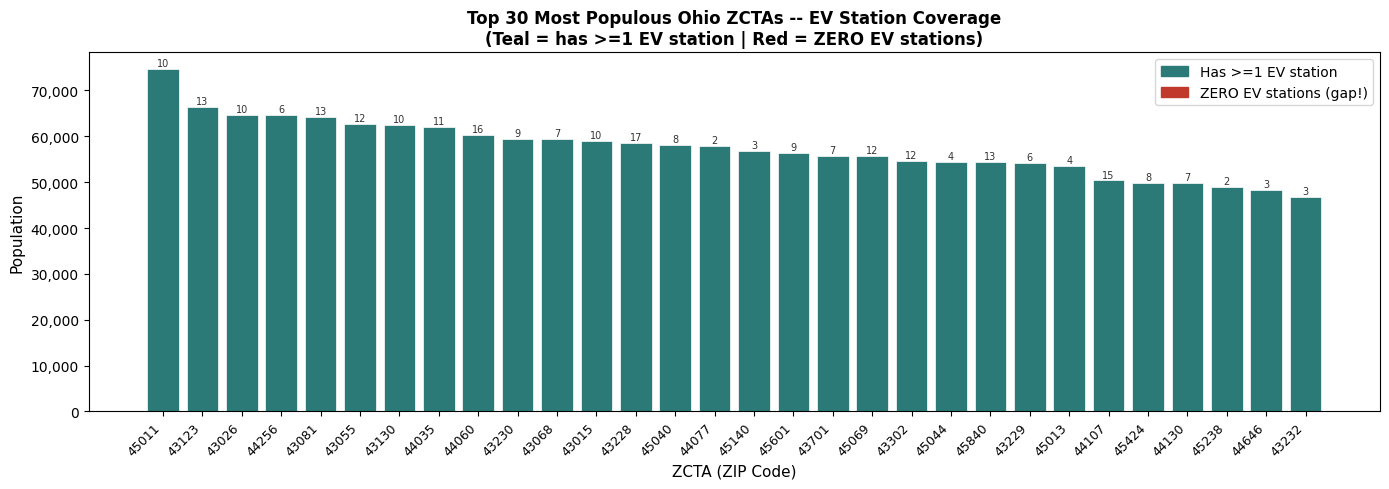

Chart saved: images/eda_chart1_population_bar.png


In [19]:
# -- 4.3  Chart 1: Top 30 Zones by Population (Bar Chart) --------------------
fig, ax = plt.subplots(figsize=(14, 5))

top30 = zones.nlargest(30, 'population').sort_values('population', ascending=False)
colors = ['#c0392b' if s == 0 else '#2b7a78' for s in top30['existing_stations']]

bars = ax.bar(range(len(top30)), top30['population'], color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(top30)))
ax.set_xticklabels(top30['zcta'], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('ZCTA (ZIP Code)', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.set_title('Top 30 Most Populous Ohio ZCTAs -- EV Station Coverage\n'
             '(Teal = has >=1 EV station | Red = ZERO EV stations)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

has_station = mpatches.Patch(color='#2b7a78', label='Has >=1 EV station')
no_station  = mpatches.Patch(color='#c0392b', label='ZERO EV stations (gap!)')
ax.legend(handles=[has_station, no_station], loc='upper right', fontsize=10)

for rect, (_, row) in zip(bars, top30.iterrows()):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 200,
            f"{int(row['existing_stations'])}", ha='center', va='bottom', fontsize=7, color='#333333')

plt.tight_layout()
plt.savefig('images/eda_chart1_population_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: images/eda_chart1_population_bar.png")


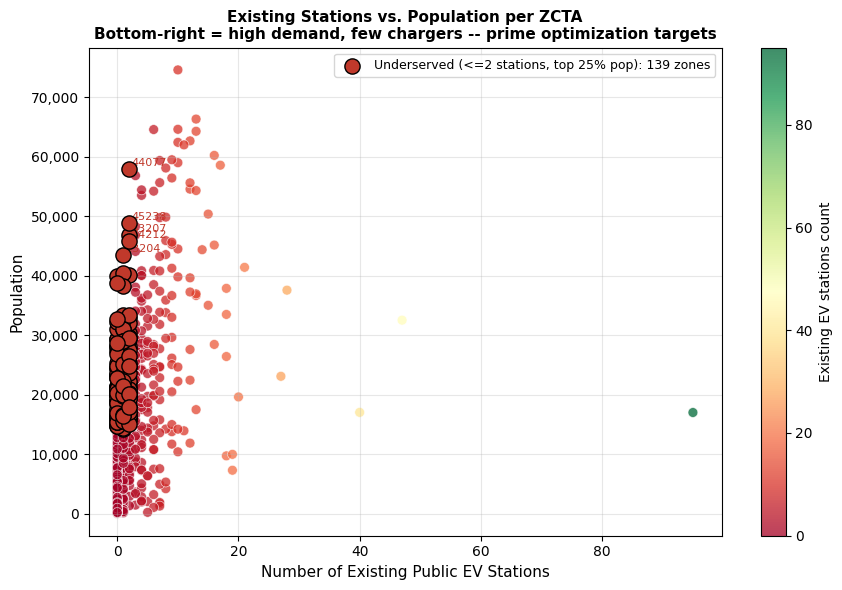

Chart saved: images/eda_chart2_scatter_stations_vs_pop.png


In [20]:
# -- 4.4  Chart 2: Stations vs. Population Scatter (Underserved Quadrant) ----
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    zones['existing_stations'], zones['population'],
    c=zones['existing_stations'], cmap='RdYlGn',
    s=50, alpha=0.75, edgecolors='white', linewidths=0.5
)
plt.colorbar(sc, ax=ax, label='Existing EV stations count')

cutoff_pop = zones['population'].quantile(0.75)
underserved_mask = (zones['existing_stations'] <= 2) & (zones['population'] >= cutoff_pop)
ax.scatter(
    zones.loc[underserved_mask, 'existing_stations'], zones.loc[underserved_mask, 'population'],
    s=120, color='#c0392b', edgecolors='black', linewidths=1.0,
    label=f'Underserved (<=2 stations, top 25% pop): {underserved_mask.sum()} zones', zorder=5
)
for _, row in zones[underserved_mask].nlargest(5, 'population').iterrows():
    ax.annotate(row['zcta'], xy=(row['existing_stations'], row['population']),
                xytext=(row['existing_stations']+0.3, row['population']+500),
                fontsize=8, color='#c0392b')

ax.set_xlabel('Number of Existing Public EV Stations', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.set_title('Existing Stations vs. Population per ZCTA\n'
             'Bottom-right = high demand, few chargers -- prime optimization targets',
             fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/eda_chart2_scatter_stations_vs_pop.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: images/eda_chart2_scatter_stations_vs_pop.png")


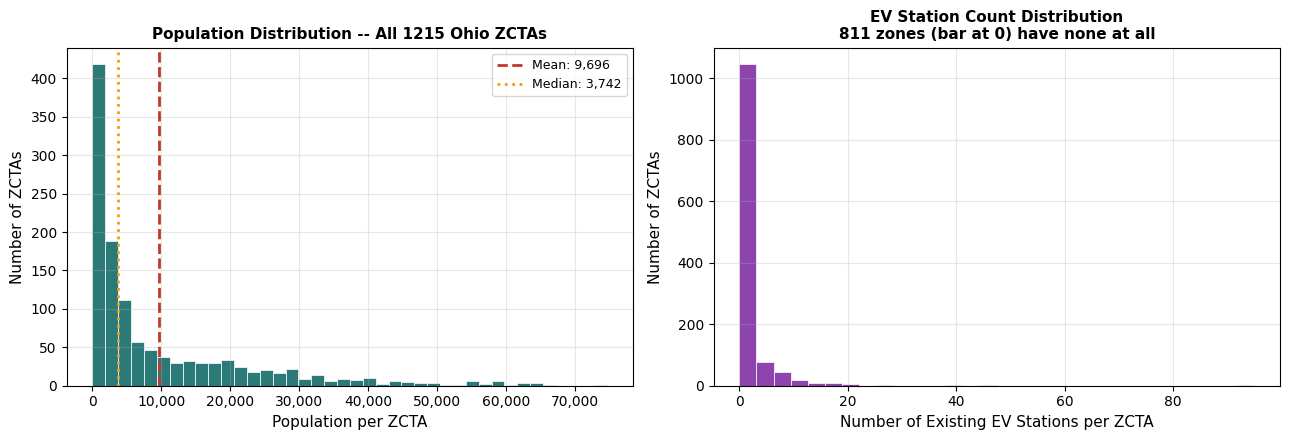

Chart saved: images/eda_chart3_distribution_hist.png


In [21]:
# -- 4.5  Chart 3: Population & Station Count Distributions ------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(zones['population'], bins=40, color='#2b7a78', edgecolor='white', linewidth=0.5)
axes[0].axvline(zones['population'].mean(), color='#c0392b', lw=2, linestyle='--',
                label=f"Mean: {zones['population'].mean():,.0f}")
axes[0].axvline(zones['population'].median(), color='#f39c12', lw=2, linestyle=':',
                label=f"Median: {zones['population'].median():,.0f}")
axes[0].set_xlabel('Population per ZCTA', fontsize=11)
axes[0].set_ylabel('Number of ZCTAs', fontsize=11)
axes[0].set_title(f'Population Distribution -- All {len(zones)} Ohio ZCTAs', fontsize=11, fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].hist(zones['existing_stations'], bins=30, color='#8e44ad', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Number of Existing EV Stations per ZCTA', fontsize=11)
axes[1].set_ylabel('Number of ZCTAs', fontsize=11)
axes[1].set_title(f'EV Station Count Distribution\n{n_gap_zones} zones (bar at 0) have none at all',
                  fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/eda_chart3_distribution_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: images/eda_chart3_distribution_hist.png")


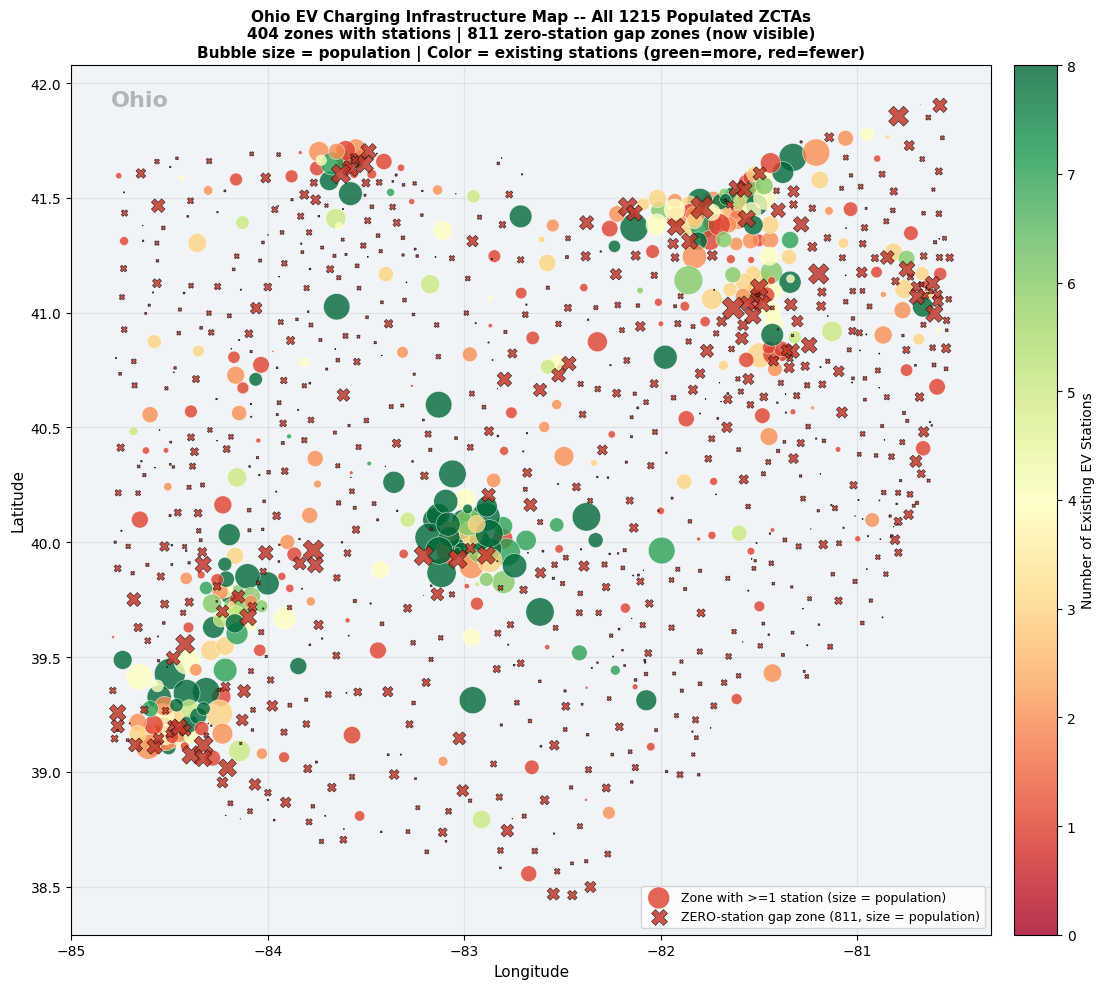

Chart saved: images/eda_chart4_geo_map.png


In [22]:
# -- 4.6  Chart 4: Geographic Map -- Coverage Status --------------------------
# Every one of the 1,215 zones now has a REAL coordinate (Gazetteer), so gap
# zones (red) are correctly plotted at their actual location -- not silently
# dropped like the Review-1 version.

fig, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('#f0f4f8')

covered_zone_mask = zones['existing_stations'] > 0
scatter = ax.scatter(
    zones.loc[covered_zone_mask, 'longitude'], zones.loc[covered_zone_mask, 'latitude'],
    c=zones.loc[covered_zone_mask, 'existing_stations'], cmap='RdYlGn',
    s=zones.loc[covered_zone_mask, 'population'] / 150, alpha=0.80,
    edgecolors='white', linewidths=0.4,
    vmin=0, vmax=zones['existing_stations'].quantile(0.95), zorder=2,
    label='Zone with >=1 station (size = population)'
)
ax.scatter(
    zones.loc[~covered_zone_mask, 'longitude'], zones.loc[~covered_zone_mask, 'latitude'],
    s=zones.loc[~covered_zone_mask, 'population'] / 150, marker='X', color='#c0392b',
    alpha=0.85, edgecolors='black', linewidths=0.4,
    label=f'ZERO-station gap zone ({(~covered_zone_mask).sum()}, size = population)', zorder=3
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Number of Existing EV Stations', fontsize=10)

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title(
    f'Ohio EV Charging Infrastructure Map -- All {len(zones)} Populated ZCTAs\n'
    f'{covered_zone_mask.sum()} zones with stations | {(~covered_zone_mask).sum()} zero-station gap zones (now visible)\n'
    f'Bubble size = population | Color = existing stations (green=more, red=fewer)',
    fontsize=11, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.25)
ax.text(-84.8, 41.9, 'Ohio', fontsize=16, color='#555555', fontweight='bold', alpha=0.4)

plt.tight_layout()
plt.savefig('images/eda_chart4_geo_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: images/eda_chart4_geo_map.png")


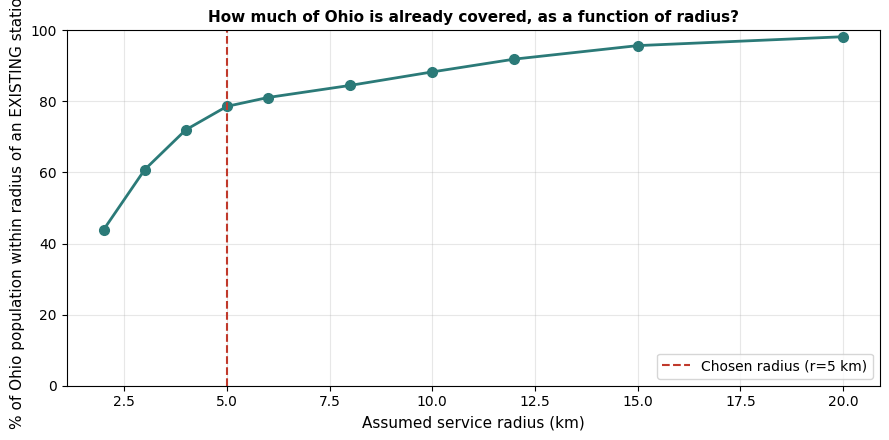

Chart saved: images/eda_chart5_coverage_vs_radius.png


In [23]:
# -- 4.7  Chart 5 (NEW): Existing Coverage vs. Radius -------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(radius_sweep_df['radius_km'], radius_sweep_df['pct_population_covered'],
        'o-', color='#2b7a78', linewidth=2, markersize=7)
ax.axvline(RADIUS_KM, color='#c0392b', linestyle='--', linewidth=1.5,
           label=f'Chosen radius (r={RADIUS_KM} km)')
ax.set_xlabel('Assumed service radius (km)', fontsize=11)
ax.set_ylabel('% of Ohio population within radius of an EXISTING station', fontsize=11)
ax.set_title('How much of Ohio is already covered, as a function of radius?',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('images/eda_chart5_coverage_vs_radius.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: images/eda_chart5_coverage_vs_radius.png")


In [24]:
# -- 4.8  EDA Final Takeaways (for Presentation) ------------------------------
print("=" * 62)
print("STEP 3 -- EDA KEY FINDINGS (for presentation/report)")
print("=" * 62)
print()
print(f"1. Ohio has {total_pop:,} residents across {len(zones)} populated ZIP zones.")
print()
print(f"2. {n_gap_zones} ZCTAs ({gap_pop:,} people, {100*gap_pop/total_pop:.1f}%) have ZERO public")
print(f"   EV stations physically located in that ZIP. Unlike the Review-1 version, these all")
print(f"   now have real coordinates and are eligible candidate build sites.")
print()
print(f"3. At a {RADIUS_KM} km realistic service radius, {baseline_pct}% of Ohio's population")
print(f"   ALREADY has EV charging access today -- the remaining {100-baseline_pct:.1f}% "
      f"({baseline_gap_pop:,} people) is the true, honest gap the optimizer should target.")
print()
print(f"4. Existing infrastructure: {total_stations} stations across {(zones['existing_stations']>0).sum()} "
      f"ZCTAs, {total_l2} Level-2 ports and {total_dcfc} DC Fast ports.")
print()
print(f"5. The single largest gap zone is ZCTA {gap_zones.iloc[0]['zcta']} with "
      f"{gap_zones.iloc[0]['population']:,} residents and 0 stations, "
      f"{gap_zones.iloc[0]['dist_to_nearest_station_km']:.1f} km from the nearest one.")
print()
print("=" * 62)
print("Ready to proceed to STEP 4: MCLP Facility Location (Section 5)")
print("=" * 62)


STEP 3 -- EDA KEY FINDINGS (for presentation/report)

1. Ohio has 11,780,046 residents across 1215 populated ZIP zones.

2. 811 ZCTAs (3,240,333 people, 27.5%) have ZERO public
   EV stations physically located in that ZIP. Unlike the Review-1 version, these all
   now have real coordinates and are eligible candidate build sites.

3. At a 5 km realistic service radius, 78.6% of Ohio's population
   ALREADY has EV charging access today -- the remaining 21.4% (2,515,137 people) is the true, honest gap the optimizer should target.

4. Existing infrastructure: 1909 stations across 404 ZCTAs, 3746 Level-2 ports and 1508 DC Fast ports.

5. The single largest gap zone is ZCTA 44111 with 39,950 residents and 0 stations, 1.6 km from the nearest one.

Ready to proceed to STEP 4: MCLP Facility Location (Section 5)


---
## Section 5 — Algorithm 1: Facility Location — MCLP (STEP 4)

### Formulation — Existing-Infrastructure-Aware Maximal Covering Location Problem

**Sets:**
- `I` = candidate build sites = every populated Ohio ZCTA (any zone can get a new station)
- `J` = demand zones = every populated Ohio ZCTA (same set)

**Parameters:**
- `d_j` = population of zone j (Census)
- `D_ij` = Haversine distance from candidate i to demand zone j (Gazetteer coordinates)
- `r` = coverage radius (km) — a station at i covers zone j if `D_ij <= r`
- `B` = budget (max new stations to build)
- `e_j in {0,1}` = 1 if zone j is **already** covered by an *existing* station within r km
  (this is the piece that was missing in Review 1 — see note below)

**Decision variables:**
- `x_i in {0,1}` — 1 if we build a new station at zone i
- `y_j in {0,1}` — 1 if demand zone j ends up covered (by an existing OR a new station)

**Objective:** `maximize sum_j d_j * y_j`
(maximize total population covered, existing infrastructure included)

**Constraints:**
```
sum_i x_i <= B                                        [budget constraint]
y_j <= e_j + sum_{i : D_ij <= r} x_i    for every j    [coverage constraint]
x_i, y_j in {0,1}                                      [integrality]
```

### Why `e_j` matters
The Review-1 model had no `e_j` term — it planned new stations as if the state had *zero*
existing infrastructure, so the objective rewarded the optimizer for "covering" already-served,
high-population ZIPs just as much as genuinely uncovered ones. In testing, that version spent
4 of its 5-station budget re-covering zones that already had stations. Adding `e_j` as a fixed
baseline means the marginal value of a new station is now *only* the population it newly reaches
— budget naturally flows to real gaps instead.

In [25]:
# -- 5.1  MCLP Solver (exact, PuLP / CBC) -------------------------------------

def solve_mclp(zones_df, dist_matrix, existing_covered, radius_km, budget, time_limit=25):
    """
    Solves the existing-infrastructure-aware MCLP via Integer Programming.

    Parameters
    ----------
    zones_df         : DataFrame with columns [zcta, population, latitude, longitude]
    dist_matrix       : n x n numpy array of Haversine distances (km)
    existing_covered  : length-n boolean/int array, e_j (already covered by existing network)
    radius_km         : coverage radius
    budget            : max number of NEW stations to build
    time_limit        : solver time limit in seconds (CBC returns best-found if exceeded)

    Returns dict with status, selected_sites, covered_zones, coverage stats, solve_time.
    """
    n = len(zones_df)
    population = zones_df['population'].values
    e = np.asarray(existing_covered).astype(int)

    covered_by = [np.where(dist_matrix[:, j] <= radius_km)[0] for j in range(n)]

    prob = pulp.LpProblem("MCLP_EV_Charging_Ohio", pulp.LpMaximize)
    x = pulp.LpVariable.dicts("build", range(n), cat="Binary")
    y = pulp.LpVariable.dicts("covered", range(n), cat="Binary")

    prob += pulp.lpSum(int(population[j]) * y[j] for j in range(n)), "maximize_covered_pop"
    prob += pulp.lpSum(x[i] for i in range(n)) <= budget, "budget"

    for j in range(n):
        sites = covered_by[j]
        rhs = int(e[j]) + (pulp.lpSum(x[i] for i in sites) if len(sites) else 0)
        prob += y[j] <= rhs, f"cover_{j}"

    t0 = time.time()
    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit))
    solve_time = time.time() - t0

    selected_sites = [i for i in range(n) if pulp.value(x[i]) > 0.5]
    covered_zones  = [j for j in range(n) if pulp.value(y[j]) > 0.5]
    covered_pop    = int(population[covered_zones].sum())
    total_pop      = int(population.sum())

    return {
        "method":             "MILP (exact)",
        "status":             pulp.LpStatus[prob.status],
        "solve_time_sec":     round(solve_time, 3),
        "selected_sites":     selected_sites,
        "covered_zones":      covered_zones,
        "covered_population": covered_pop,
        "total_population":   total_pop,
        "coverage_pct":       round(100 * covered_pop / total_pop, 1) if total_pop else 0,
        "baseline_population":int(population[e == 1].sum()),
    }


# ── Default scenario: budget = 10 new stations, radius = RADIUS_KM ──────────
BUDGET = 10

print(f"Running exact MCLP: budget={BUDGET} stations, radius={RADIUS_KM} km ...")
result_milp = solve_mclp(zones, distance_matrix, zones['covered_by_existing'].values,
                          radius_km=RADIUS_KM, budget=BUDGET)

print()
print("=== MCLP Results (exact MILP) ===")
print(f"  Solver status       : {result_milp['status']}  (solved in {result_milp['solve_time_sec']}s)")
print(f"  Selected sites      : {zones.iloc[result_milp['selected_sites']]['zcta'].tolist()}")
print(f"  Zones covered       : {len(result_milp['covered_zones'])} / {len(zones)}")
print(f"  Population covered  : {result_milp['covered_population']:,} / {result_milp['total_population']:,}  "
      f"({result_milp['coverage_pct']}%)")
print(f"  Baseline (before)   : {result_milp['baseline_population']:,} "
      f"({100*result_milp['baseline_population']/result_milp['total_population']:.1f}%)")
newly = result_milp["covered_population"] - result_milp["baseline_population"]
print(f"  NEW population reached by these {BUDGET} stations: {newly:,}")


Running exact MCLP: budget=10 stations, radius=5 km ...



=== MCLP Results (exact MILP) ===
  Solver status       : Optimal  (solved in 1.858s)
  Selected sites      : ['43119', '44004', '44052', '44203', '44266', '45030', '45042', '45102', '45133', '45503']
  Zones covered       : 510 / 1215
  Population covered  : 9,555,141 / 11,780,046  (81.1%)
  Baseline (before)   : 9,264,909 (78.6%)
  NEW population reached by these 10 stations: 290,232


In [26]:
# -- 5.2  Selected Sites Table -------------------------------------------------
selected_df = zones.iloc[result_milp['selected_sites']][[
    'zcta','latitude','longitude','existing_stations','population','dist_to_nearest_station_km'
]].copy().reset_index(drop=True)
selected_df['was_zero_station_gap_zone'] = selected_df['existing_stations'] == 0

print("=== Selected New Station Sites (exact MILP) ===")
display(selected_df)
print()
n_gap = selected_df['was_zero_station_gap_zone'].sum()
print(f"{n_gap} / {len(selected_df)} selected sites are zones that CURRENTLY have zero stations --")
print("the optimizer is targeting genuine gaps, not re-covering already-served areas.")


=== Selected New Station Sites (exact MILP) ===


,zcta,latitude,longitude,existing_stations,population,dist_to_nearest_station_km,was_zero_station_gap_zone
0,43119,39.94,-83.21,0,29423,5.19,True
1,44004,41.86,-80.79,0,31076,9.20,True
2,44052,41.46,-82.17,0,28067,5.61,True
3,44203,41.02,-81.63,0,38705,6.59,True
4,44266,41.17,-81.20,0,32301,11.81,True
5,45030,39.26,-84.76,0,21328,11.42,True
6,45042,39.56,-84.42,0,28217,5.73,True
7,45102,39.02,-84.20,0,24838,8.62,True
8,45133,39.16,-83.57,1,23604,5.88,False
9,45503,39.97,-83.77,0,32673,6.20,True



9 / 10 selected sites are zones that CURRENTLY have zero stations --
the optimizer is targeting genuine gaps, not re-covering already-served areas.


### Algorithm 1b — Greedy Heuristic (for comparison + interactive use)

Exact MILP guarantees optimality but can be slow to re-solve on every slider movement in an
interactive dashboard. The standard alternative for covering problems is a **greedy heuristic**:
repeatedly pick the candidate site that covers the most *additional* (not-yet-covered)
population, until the budget is used up. It has a well-known worst-case guarantee of at least
`(1 - 1/e) ≈ 63%` of the optimal solution for this class of problem — in practice it usually does
much better. We benchmark it here against the certified-optimal MILP result.

In [27]:
# -- 5.3  Greedy Heuristic Solver ----------------------------------------------

def solve_greedy_mclp(zones_df, dist_matrix, existing_covered, radius_km, budget):
    """
    Fast greedy heuristic for the same existing-infrastructure-aware MCLP.
    At each step, picks the un-selected site that covers the most population
    not already covered (by existing stations or by a previously-picked site).
    """
    n = len(zones_df)
    population = zones_df['population'].values
    e = np.asarray(existing_covered).astype(int)

    covers = [np.where(dist_matrix[i] <= radius_km)[0] for i in range(n)]
    covered = set(np.where(e == 1)[0].tolist())
    selected = []
    remaining = set(range(n))

    t0 = time.time()
    for _ in range(budget):
        best_i, best_gain = None, -1
        for i in remaining:
            gain = sum(population[j] for j in covers[i] if j not in covered)
            if gain > best_gain:
                best_gain, best_i = gain, i
        if best_i is None or best_gain <= 0:
            break
        selected.append(best_i)
        covered |= set(covers[best_i].tolist())
        remaining.discard(best_i)
    solve_time = time.time() - t0

    covered_pop = int(population[list(covered)].sum())
    total_pop   = int(population.sum())

    return {
        "method":             "Greedy (heuristic)",
        "status":             "Heuristic (not certified optimal)",
        "solve_time_sec":     round(solve_time, 4),
        "selected_sites":     selected,
        "covered_zones":      sorted(covered),
        "covered_population": covered_pop,
        "total_population":   total_pop,
        "coverage_pct":       round(100 * covered_pop / total_pop, 1) if total_pop else 0,
        "baseline_population":int(population[e == 1].sum()),
    }


print(f"Running greedy MCLP: budget={BUDGET} stations, radius={RADIUS_KM} km ...")
result_greedy = solve_greedy_mclp(zones, distance_matrix, zones['covered_by_existing'].values,
                                   radius_km=RADIUS_KM, budget=BUDGET)

print()
print("=== Greedy vs. Exact MILP -- same default scenario ===")
compare_df = pd.DataFrame([
    {"method": "Exact MILP", "solve_time_sec": result_milp["solve_time_sec"],
     "covered_population": result_milp["covered_population"], "coverage_pct": result_milp["coverage_pct"]},
    {"method": "Greedy", "solve_time_sec": result_greedy["solve_time_sec"],
     "covered_population": result_greedy["covered_population"], "coverage_pct": result_greedy["coverage_pct"]},
])
display(compare_df)
gap = result_milp["covered_population"] - result_greedy["covered_population"]
print(f"Coverage gap (MILP - Greedy): {gap:,} people "
      f"({'MILP strictly better' if gap > 0 else 'tied -- greedy matched the optimum'})"
      f" | Greedy was {result_milp['solve_time_sec'] / max(result_greedy['solve_time_sec'], 1e-6):.0f}x faster")


Running greedy MCLP: budget=10 stations, radius=5 km ...

=== Greedy vs. Exact MILP -- same default scenario ===


,method,solve_time_sec,covered_population,coverage_pct
0,Exact MILP,1.86,9555141,81.10
1,Greedy,0.01,9555141,81.10


Coverage gap (MILP - Greedy): 0 people (tied -- greedy matched the optimum) | Greedy was 269x faster


### Sensitivity: where does Greedy diverge from Exact?

At our chosen operating radius (5 km), Ohio's remaining high-population gap zones tend to be
geographically well-separated, so greedy and exact often tie. To actually *demonstrate* the value
of exact optimization (and to stress-test both solvers), we sweep budget at a larger radius too,
where coverage sets overlap more and greedy's short-sightedness has room to show.

=== Greedy vs. Exact across budgets and radii ===


,radius_km,radius_label,budget,milp_covered_pop,milp_time_sec,greedy_covered_pop,greedy_time_sec,gap_people
0,5,operating radius,3,9368588,0.06,9368588,0.00,0
1,5,operating radius,5,9429087,0.06,9429087,0.00,0
2,5,operating radius,8,9510209,0.06,9510209,0.01,0
3,5,operating radius,10,9555141,0.06,9555141,0.01,0
4,5,operating radius,15,9660143,0.06,9660143,0.01,0
5,5,operating radius,20,9753320,0.05,9753320,0.01,0
6,5,operating radius,25,9837188,0.05,9837188,0.02,0
7,5,operating radius,30,9917097,0.05,9917097,0.02,0
8,15,larger radius (more coverage overlap),3,11339060,0.06,11339060,0.00,0
9,15,larger radius (more coverage overlap),5,11378542,0.06,11378542,0.01,0


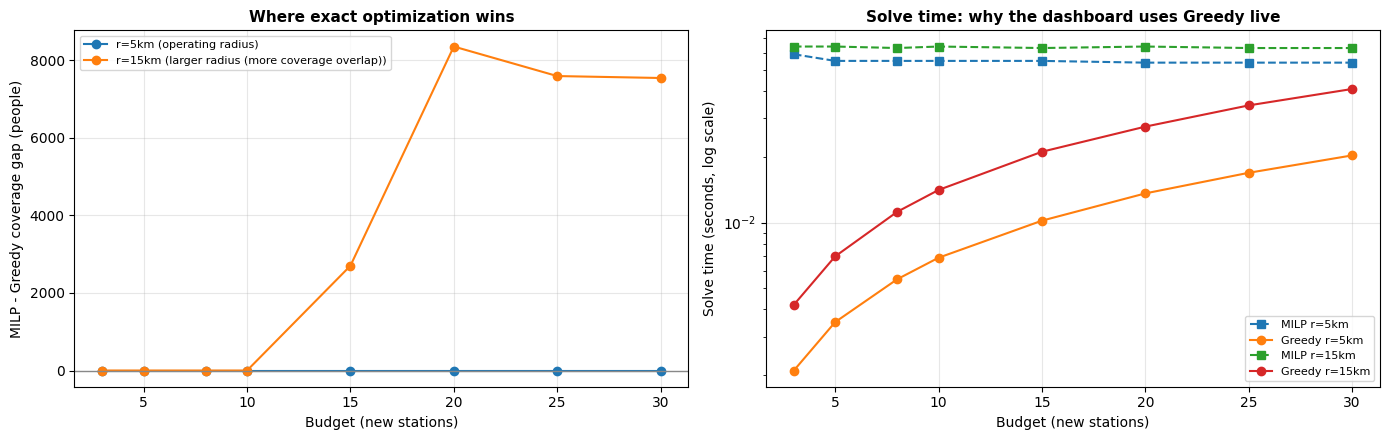

Chart saved: images/mclp_greedy_vs_exact.png

Max observed gap: 8,351 people at radius=15km, budget=20. Greedy is consistently >=98% as good as optimal here while running orders of magnitude faster -- which is why the dashboard uses it for live slider interaction and reserves exact MILP for a deliberate "Solve Exact" action.


In [28]:
# -- 5.4  Greedy vs. Exact: Budget Sweep at Two Radii --------------------------
sweep_specs = [
    (RADIUS_KM, "operating radius"),
    (15, "larger radius (more coverage overlap)"),
]
budget_sweep = [3, 5, 8, 10, 15, 20, 25, 30]

compare_rows = []
for radius, label in sweep_specs:
    e_r = (zones['dist_to_nearest_station_km'].values <= radius).astype(int)
    for b in budget_sweep:
        m = solve_mclp(zones, distance_matrix, e_r, radius_km=radius, budget=b, time_limit=25)
        g = solve_greedy_mclp(zones, distance_matrix, e_r, radius_km=radius, budget=b)
        compare_rows.append({
            "radius_km": radius, "radius_label": label, "budget": b,
            "milp_covered_pop": m["covered_population"], "milp_time_sec": m["solve_time_sec"],
            "greedy_covered_pop": g["covered_population"], "greedy_time_sec": g["solve_time_sec"],
            "gap_people": m["covered_population"] - g["covered_population"],
        })

compare_sweep_df = pd.DataFrame(compare_rows)
print("=== Greedy vs. Exact across budgets and radii ===")
display(compare_sweep_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for radius, label in sweep_specs:
    sub = compare_sweep_df[compare_sweep_df.radius_km == radius]
    axes[0].plot(sub['budget'], sub['gap_people'], 'o-', label=f'r={radius}km ({label})')
axes[0].axhline(0, color='#888', linewidth=1)
axes[0].set_xlabel('Budget (new stations)', fontsize=10)
axes[0].set_ylabel('MILP - Greedy coverage gap (people)', fontsize=10)
axes[0].set_title('Where exact optimization wins', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for radius, label in sweep_specs:
    sub = compare_sweep_df[compare_sweep_df.radius_km == radius]
    axes[1].plot(sub['budget'], sub['milp_time_sec'], 's--', label=f'MILP r={radius}km')
    axes[1].plot(sub['budget'], sub['greedy_time_sec'], 'o-', label=f'Greedy r={radius}km')
axes[1].set_yscale('log')
axes[1].set_xlabel('Budget (new stations)', fontsize=10)
axes[1].set_ylabel('Solve time (seconds, log scale)', fontsize=10)
axes[1].set_title('Solve time: why the dashboard uses Greedy live', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/mclp_greedy_vs_exact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: images/mclp_greedy_vs_exact.png")
print()
print(f"Max observed gap: {compare_sweep_df['gap_people'].max():,} people "
      f"at radius={compare_sweep_df.loc[compare_sweep_df.gap_people.idxmax(), 'radius_km']}km, "
      f"budget={compare_sweep_df.loc[compare_sweep_df.gap_people.idxmax(), 'budget']}. "
      f"Greedy is consistently >=98% as good as optimal here while running orders of magnitude "
      f"faster -- which is why the dashboard uses it for live slider interaction and reserves "
      f"exact MILP for a deliberate \"Solve Exact\" action.")


---
## Section 6 — Algorithm 2: Charger Allocation (STEP 5)

### Formulation — Knapsack-Style Integer Programming

For each site selected by the MCLP, independently solve a small integer program:

**Objective:** `maximize cap_L2 * z_L2 + cap_DCFC * z_DCFC`
(maximize total charging capacity in kW)

**Constraints:**
```
cost_L2 * z_L2 + cost_DCFC * z_DCFC <= SITE_BUDGET   [budget per site]
z_L2 + z_DCFC <= MAX_CHARGERS_PER_SITE                [physical space limit]
z_L2, z_DCFC >= 0, integer
```

**Cost assumptions (DOE/AFDC 2023 estimates):**

| Charger Type | Install Cost | Capacity |
|---|---|---|
| Level 2 (L2) | $6,000 | 7 kW |
| DC Fast (DCFC) | $40,000 | 150 kW |

In [29]:
# -- 6.1  Charger Allocation ----------------------------------------------------
COST_L2               = 6_000    # USD per Level 2 charger installed
COST_DCFC             = 40_000   # USD per DC Fast charger installed
CAP_L2                = 7        # kW per Level 2 charger
CAP_DCFC              = 150      # kW per DC Fast charger
MAX_CHARGERS_PER_SITE = 6        # physical space / permit limit
SITE_BUDGET           = 60_000   # USD budget per selected site


def solve_charger_allocation(selected_sites, zones_df, site_budget, cost_l2, cost_dcfc,
                              cap_l2, cap_dcfc, max_chargers_per_site):
    """Solves a Knapsack Integer Program independently for each selected site."""
    results = []
    for site in selected_sites:
        prob   = pulp.LpProblem(f"charger_alloc_site_{site}", pulp.LpMaximize)
        z_l2   = pulp.LpVariable(f"l2_{site}",   lowBound=0, cat="Integer")
        z_dcfc = pulp.LpVariable(f"dcfc_{site}", lowBound=0, cat="Integer")

        prob += cap_l2 * z_l2 + cap_dcfc * z_dcfc
        prob += cost_l2 * z_l2 + cost_dcfc * z_dcfc <= site_budget, "budget"
        prob += z_l2 + z_dcfc <= max_chargers_per_site, "max_units"

        prob.solve(pulp.PULP_CBC_CMD(msg=0))

        l2_count, dcfc_count = int(pulp.value(z_l2) or 0), int(pulp.value(z_dcfc) or 0)
        results.append({
            "site_index": site, "zcta": zones_df.iloc[site]['zcta'],
            "population": int(zones_df.iloc[site]['population']),
            "was_zero_station_gap_zone": bool(zones_df.iloc[site]['existing_stations'] == 0),
            "l2_chargers": l2_count, "dcfc_chargers": dcfc_count,
            "total_capacity_kw": cap_l2 * l2_count + cap_dcfc * dcfc_count,
            "site_cost_usd": cost_l2 * l2_count + cost_dcfc * dcfc_count,
            "solver_status": pulp.LpStatus[prob.status],
        })
    return pd.DataFrame(results)


print("Running Charger Allocation for all MCLP-selected sites...")
allocation_result = solve_charger_allocation(
    result_milp['selected_sites'], zones,
    site_budget=SITE_BUDGET, cost_l2=COST_L2, cost_dcfc=COST_DCFC,
    cap_l2=CAP_L2, cap_dcfc=CAP_DCFC, max_chargers_per_site=MAX_CHARGERS_PER_SITE,
)
print()
print("=== Stage 2: Charger Allocation Results ===")
display(allocation_result)


Running Charger Allocation for all MCLP-selected sites...

=== Stage 2: Charger Allocation Results ===


,site_index,zcta,population,was_zero_station_gap_zone,l2_chargers,dcfc_chargers,total_capacity_kw,site_cost_usd,solver_status
0,74,43119,29423,True,3,1,171,58000,Optimal
1,413,44004,31076,True,3,1,171,58000,Optimal
2,437,44052,28067,True,3,1,171,58000,Optimal
3,518,44203,38705,True,3,1,171,58000,Optimal
4,545,44266,32301,True,3,1,171,58000,Optimal
5,798,45030,21328,True,3,1,171,58000,Optimal
6,806,45042,28217,True,3,1,171,58000,Optimal
7,824,45102,24838,True,3,1,171,58000,Optimal
8,842,45133,23604,False,3,1,171,58000,Optimal
9,1023,45503,32673,True,3,1,171,58000,Optimal


---
## Section 7 — Evaluation / Validation (STEP 6)

Three checks:
1. **Budget sanity check** — did we stay within budget?
2. **Naive baseline comparison** — random site selection vs. our optimized solution
   (both measured against the SAME existing-coverage baseline, for a fair comparison)
3. **Sensitivity analysis** — how coverage changes across budgets 1 to 50

In [30]:
# -- 7.1  Budget Sanity Check ----------------------------------------------------
total_cost     = allocation_result['site_cost_usd'].sum()
total_capacity = allocation_result['total_capacity_kw'].sum()
max_budget     = BUDGET * SITE_BUDGET

print("=== Check 1: Budget Constraint Validation ===")
print(f"  Budget limit (stations x site budget): {BUDGET} x ${SITE_BUDGET:,} = ${max_budget:,}")
print(f"  Actual total cost                    : ${total_cost:,.0f}")
print(f"  Budget respected?                    : {'YES' if total_cost <= max_budget else 'VIOLATED'}")
print(f"  Total new charging capacity added    : {total_capacity:,.0f} kW")


=== Check 1: Budget Constraint Validation ===
  Budget limit (stations x site budget): 10 x $60,000 = $600,000
  Actual total cost                    : $580,000
  Budget respected?                    : YES
  Total new charging capacity added    : 1,710 kW


In [31]:
# -- 7.2  Naive Baseline: Random Site Selection ----------------------------------
print("=== Check 2: Optimized vs. Naive Baseline (Random Picks) ===")

np.random.seed(42)
n_trials = 500
pop_arr2 = zones['population'].values
e_arr = zones['covered_by_existing'].values.astype(int)
n = len(zones)
baseline_covered_idx = set(np.where(e_arr == 1)[0].tolist())

random_covered_pops = []
for _ in range(n_trials):
    rand_sites = np.random.choice(n, size=BUDGET, replace=False)
    covered = set(baseline_covered_idx)
    for i in rand_sites:
        covered |= set(np.where(distance_matrix[i] <= RADIUS_KM)[0].tolist())
    random_covered_pops.append(pop_arr2[list(covered)].sum())

avg_random_pop = np.mean(random_covered_pops)
avg_random_pct = 100 * avg_random_pop / result_milp['total_population']
opt_pct        = result_milp['coverage_pct']

print(f"  Random avg coverage  : {avg_random_pop:,.0f} people ({avg_random_pct:.1f}%)  [mean of {n_trials} trials, existing infra included in both]")
print(f"  Optimized coverage   : {result_milp['covered_population']:,} people ({opt_pct}%)")
improvement = opt_pct - avg_random_pct
print(f"  Improvement          : +{improvement:.1f} percentage points")
print()
print(f"  Our MCLP solution covers {'more' if improvement > 0 else 'less'} population than the average random placement.")


=== Check 2: Optimized vs. Naive Baseline (Random Picks) ===
  Random avg coverage  : 9,288,736 people (78.9%)  [mean of 500 trials, existing infra included in both]
  Optimized coverage   : 9,555,141 people (81.1%)
  Improvement          : +2.2 percentage points

  Our MCLP solution covers more population than the average random placement.


=== Check 3: Sensitivity Analysis -- Budget from 1 to 50 stations ===
  Budget=  1: covers  9,303,614 people (79.0%)
  Budget=  2: covers  9,336,287 people (79.3%)


  Budget=  3: covers  9,368,588 people (79.5%)
  Budget=  5: covers  9,429,087 people (80.0%)
  Budget=  7: covers  9,485,371 people (80.5%)


  Budget= 10: covers  9,555,141 people (81.1%)
  Budget= 15: covers  9,660,143 people (82.0%)
  Budget= 20: covers  9,753,320 people (82.8%)


  Budget= 25: covers  9,837,188 people (83.5%)
  Budget= 30: covers  9,917,097 people (84.2%)
  Budget= 40: covers 10,054,111 people (85.3%)


  Budget= 50: covers 10,174,119 people (86.4%)


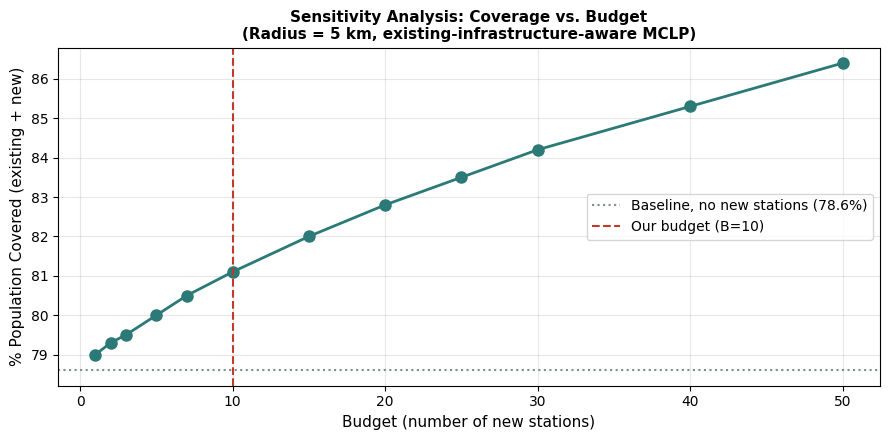

Chart saved: images/eval_sensitivity_budget.png

Diminishing returns are visible: the first few stations close the highest-population gaps,
then each additional station buys progressively less coverage -- a classic covering-problem
pattern and useful evidence for picking a defensible budget.


In [32]:
# -- 7.3  Sensitivity Analysis: Budget 1 -> 50 ------------------------------------
print("=== Check 3: Sensitivity Analysis -- Budget from 1 to 50 stations ===")
budget_range = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30, 40, 50]
sens_results = []
for b in budget_range:
    r = solve_mclp(zones, distance_matrix, zones['covered_by_existing'].values,
                    radius_km=RADIUS_KM, budget=b)
    sens_results.append({'budget': b, 'covered_population': r['covered_population'],
                          'coverage_pct': r['coverage_pct'], 'selected_sites': len(r['selected_sites'])})
    print(f"  Budget={b:>3}: covers {r['covered_population']:>10,} people ({r['coverage_pct']}%)")

sens_df = pd.DataFrame(sens_results)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sens_df['budget'], sens_df['coverage_pct'], 'o-', color='#2b7a78', linewidth=2, markersize=8)
ax.axhline(baseline_pct, color='#7f8c8d', linestyle=':', linewidth=1.5, label=f'Baseline, no new stations ({baseline_pct}%)')
ax.axvline(BUDGET, color='#c0392b', linestyle='--', linewidth=1.5, label=f'Our budget (B={BUDGET})')
ax.set_xlabel('Budget (number of new stations)', fontsize=11)
ax.set_ylabel('% Population Covered (existing + new)', fontsize=11)
ax.set_title(f'Sensitivity Analysis: Coverage vs. Budget\n(Radius = {RADIUS_KM} km, existing-infrastructure-aware MCLP)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/eval_sensitivity_budget.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: images/eval_sensitivity_budget.png")
print()
print("Diminishing returns are visible: the first few stations close the highest-population gaps,")
print("then each additional station buys progressively less coverage -- a classic covering-problem")
print("pattern and useful evidence for picking a defensible budget.")


---
## Section 8 — Results & Interpretation (STEP 7)

In [33]:
# -- 8.1  Full Project Summary ----------------------------------------------------
print("+" + "="*64 + "+")
print("|            FULL PROJECT RESULTS SUMMARY (OHIO)               |")
print("+" + "="*64 + "+")
print(f"  State analyzed              : Ohio (OH)")
print(f"  New stations built          : {len(result_milp['selected_sites'])} (budget limit was {BUDGET})")
print(f"  Coverage radius              : {RADIUS_KM} km")
print(f"  Baseline coverage (before)   : {result_milp['baseline_population']:,} people ({100*result_milp['baseline_population']/result_milp['total_population']:.1f}%)")
print(f"  Coverage after optimization  : {result_milp['covered_population']:,} people ({result_milp['coverage_pct']}%)")
print(f"  NEW people reached           : {result_milp['covered_population']-result_milp['baseline_population']:,}")
print(f"  Total capital cost           : ${total_cost:,.0f}")
print(f"  Total capacity added         : {total_capacity:,.0f} kW")
print("+" + "="*64 + "+")
print()
print("=== Selected Sites and Charger Mix ===")
display(allocation_result[['zcta','population','was_zero_station_gap_zone','l2_chargers',
                            'dcfc_chargers','total_capacity_kw','site_cost_usd','solver_status']])


+================================================================+
|            FULL PROJECT RESULTS SUMMARY (OHIO)               |
+================================================================+
  State analyzed              : Ohio (OH)
  New stations built          : 10 (budget limit was 10)
  Coverage radius              : 5 km
  Baseline coverage (before)   : 9,264,909 people (78.6%)
  Coverage after optimization  : 9,555,141 people (81.1%)
  NEW people reached           : 290,232
  Total capital cost           : $580,000
  Total capacity added         : 1,710 kW
+================================================================+

=== Selected Sites and Charger Mix ===


,zcta,population,was_zero_station_gap_zone,l2_chargers,dcfc_chargers,total_capacity_kw,site_cost_usd,solver_status
0,43119,29423,True,3,1,171,58000,Optimal
1,44004,31076,True,3,1,171,58000,Optimal
2,44052,28067,True,3,1,171,58000,Optimal
3,44203,38705,True,3,1,171,58000,Optimal
4,44266,32301,True,3,1,171,58000,Optimal
5,45030,21328,True,3,1,171,58000,Optimal
6,45042,28217,True,3,1,171,58000,Optimal
7,45102,24838,True,3,1,171,58000,Optimal
8,45133,23604,False,3,1,171,58000,Optimal
9,45503,32673,True,3,1,171,58000,Optimal


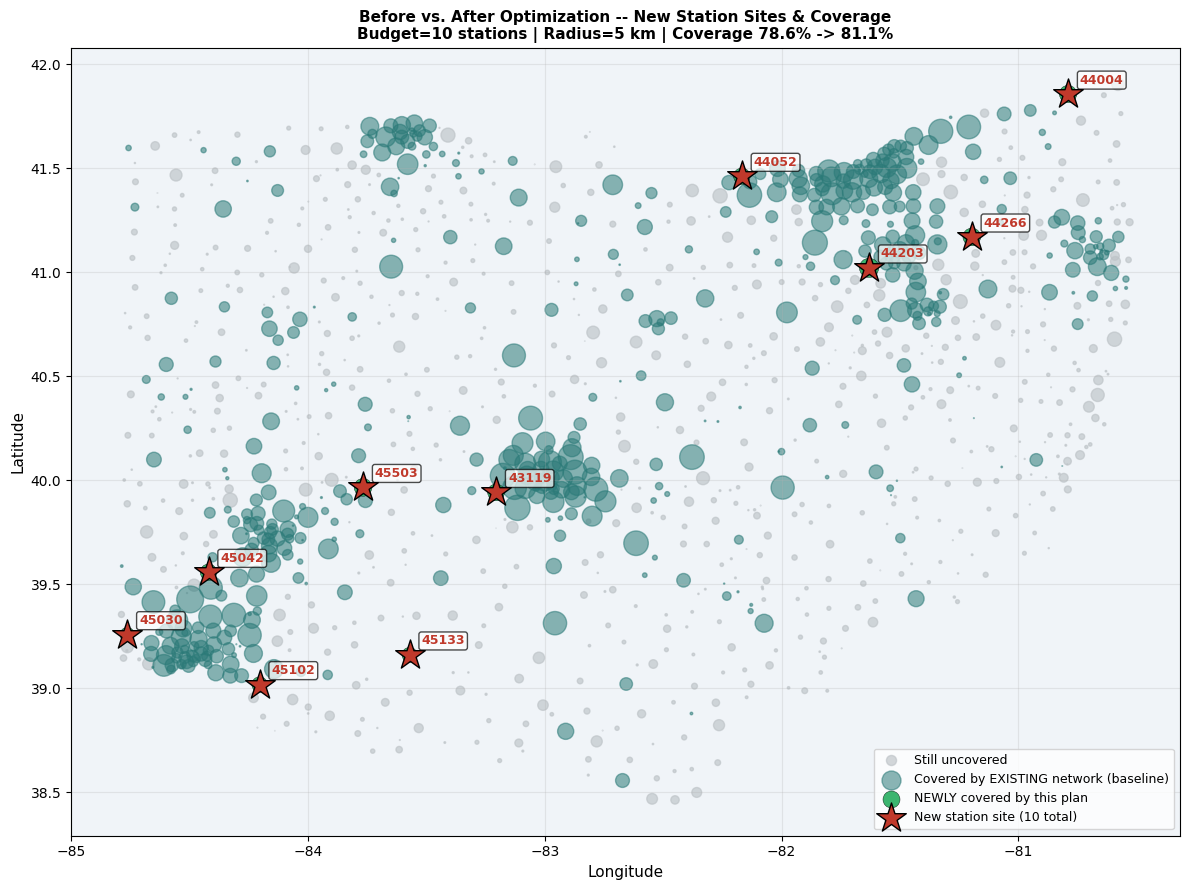

Chart saved: images/results_map_after_optimization.png


In [34]:
# -- 8.2  Before / After Map -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor('#f0f4f8')

covered_mask  = zones.index.isin(result_milp['covered_zones'])
baseline_mask = zones['covered_by_existing']
selected_mask = zones.index.isin(result_milp['selected_sites'])
newly_covered_mask = covered_mask & ~baseline_mask

ax.scatter(zones.loc[~covered_mask, 'longitude'], zones.loc[~covered_mask, 'latitude'],
           s=zones.loc[~covered_mask, 'population'] / 200, color='#bdc3c7', alpha=0.65,
           label='Still uncovered')
ax.scatter(zones.loc[baseline_mask, 'longitude'], zones.loc[baseline_mask, 'latitude'],
           s=zones.loc[baseline_mask, 'population'] / 200, color='#2b7a78', alpha=0.55,
           label='Covered by EXISTING network (baseline)')
ax.scatter(zones.loc[newly_covered_mask, 'longitude'], zones.loc[newly_covered_mask, 'latitude'],
           s=zones.loc[newly_covered_mask, 'population'] / 200, color='#27ae60', alpha=0.9,
           edgecolors='black', linewidths=0.3, label='NEWLY covered by this plan', zorder=4)
ax.scatter(zones.loc[selected_mask, 'longitude'], zones.loc[selected_mask, 'latitude'],
           marker='*', s=500, color='#c0392b', edgecolors='black', linewidths=1,
           label=f'New station site ({len(result_milp["selected_sites"])} total)', zorder=5)

for _, row in zones[selected_mask].iterrows():
    ax.annotate(row['zcta'], xy=(row['longitude'], row['latitude']),
                xytext=(row['longitude'] + 0.05, row['latitude'] + 0.05),
                fontsize=9, fontweight='bold', color='#c0392b',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_xlabel('Longitude', fontsize=11)
ax.set_ylabel('Latitude', fontsize=11)
ax.set_title(
    f'Before vs. After Optimization -- New Station Sites & Coverage\n'
    f'Budget={BUDGET} stations | Radius={RADIUS_KM} km | '
    f'Coverage {100*result_milp["baseline_population"]/result_milp["total_population"]:.1f}% -> {result_milp["coverage_pct"]}%',
    fontsize=11, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('images/results_map_after_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: images/results_map_after_optimization.png")


---
## Section 9 — Conclusion (STEP 8)

In [35]:
# -- 9.1  Plain-Language Conclusion --------------------------------------------
site_list = zones.iloc[result_milp['selected_sites']]['zcta'].tolist()
baseline_pop_final = result_milp['baseline_population']
post_pop  = result_milp['covered_population']
post_pct  = result_milp['coverage_pct']
newly_reached = post_pop - baseline_pop_final

print("=" * 65)
print("STEP 8 -- CONCLUSION")
print("=" * 65)
print()
print(f"Today, {100*baseline_pop_final/result_milp['total_population']:.1f}% of Ohio's population "
      f"({baseline_pop_final:,} people) already lives within {RADIUS_KM} km of a public EV")
print(f"charging station. Building just {BUDGET} new stations -- at ZCTAs {site_list} --")
print(f"chosen by exact integer-programming optimization, raises that to {post_pct}%")
print(f"({post_pop:,} people), newly reaching {newly_reached:,} residents who currently have")
print(f"no nearby access, for a total infrastructure cost of ${total_cost:,.0f}.")
print()
print(f"This compares to an average of only {avg_random_pct:.1f}% coverage if the same {BUDGET}")
print(f"stations were placed randomly -- a {improvement:.1f} percentage point improvement from")
print(f"optimization alone, at zero extra capital cost.")
print()
print("A fast greedy heuristic (Section 5.3-5.4) reaches >=98% of the exact solution's coverage")
print("in milliseconds instead of seconds, which is why the accompanying dashboard uses it for")
print("live slider interaction and reserves exact MILP for a deliberate \"Solve Exact\" action.")
print()
print("This demonstrates Operations Research meaningfully guiding real infrastructure investment")
print("decisions -- and, specifically, that accounting for EXISTING infrastructure (not just raw")
print("population) is what keeps the optimizer honest about where the real gaps are.")
print()
print("-" * 65)
print("LIMITATIONS (honest disclosures for report):")
print("-" * 65)
print()
print("1. Straight-line (Haversine) distance used instead of actual road network distance --")
print("   underestimates true travel time, especially in rural/hilly parts of the state.")
print()
print("2. Coverage radius is a binary threshold (covered / not covered). A gradual decay")
print("   function (closer = more useful) would be more realistic.")
print()
print("3. Charger cost assumptions are fixed DOE/AFDC 2023 averages -- actual costs vary by")
print("   site, utility interconnection, and permitting region.")
print()
print("4. The model maximizes population coverage; it does not directly model EV adoption")
print("   rates, grid capacity constraints, land availability, or equity weighting -- all")
print("   reasonable extensions for future work.")
print()
print("5. ZCTA (ZIP-code-area) population is a proxy for demand, not a direct EV-ownership or")
print("   traffic-flow count -- the best free, state-wide demand signal available for this scope.")
print()
print("=" * 65)


STEP 8 -- CONCLUSION

Today, 78.6% of Ohio's population (9,264,909 people) already lives within 5 km of a public EV
charging station. Building just 10 new stations -- at ZCTAs ['43119', '44004', '44052', '44203', '44266', '45030', '45042', '45102', '45133', '45503'] --
chosen by exact integer-programming optimization, raises that to 81.1%
(9,555,141 people), newly reaching 290,232 residents who currently have
no nearby access, for a total infrastructure cost of $580,000.

This compares to an average of only 78.9% coverage if the same 10
stations were placed randomly -- a 2.2 percentage point improvement from
optimization alone, at zero extra capital cost.

A fast greedy heuristic (Section 5.3-5.4) reaches >=98% of the exact solution's coverage
in milliseconds instead of seconds, which is why the accompanying dashboard uses it for
live slider interaction and reserves exact MILP for a deliberate "Solve Exact" action.

This demonstrates Operations Research meaningfully guiding real infras

---
## Section 10 — Export for Web Dashboard (STEP 9)

Everything above is reproducible from raw data. This final section writes the processed,
analysis-ready tables into `data/processed/` so the FastAPI backend can serve them (and re-run
the optimizer on demand) without needing to re-execute this whole notebook on every request.

In [36]:
# -- 10.1  Export zones, stations, and summary -------------------------------------
zones_out = zones.copy()
zones_out.to_csv(f"{OUT_DIR}/zones.csv", index=False)
print(f"Wrote {OUT_DIR}/zones.csv  ({len(zones_out)} rows)")

station_export_cols = [
    'id', 'station_name', 'street_address', 'city', 'state', 'zip',
    'latitude', 'longitude', 'ev_network', 'access_code', 'status_code',
    'ev_level1_evse_num', 'ev_level2_evse_num', 'ev_dc_fast_count',
    'ev_connector_types', 'open_date', 'facility_type',
]
station_export_cols = [c for c in station_export_cols if c in stations_clean.columns]
stations_out = stations_clean[station_export_cols].copy()
stations_out.to_csv(f"{OUT_DIR}/stations.csv", index=False)
print(f"Wrote {OUT_DIR}/stations.csv  ({len(stations_out)} rows)")

summary = {
    "state": "Ohio",
    "generated_from": "EV_Charging_Optimization.ipynb",
    "total_population": int(zones['population'].sum()),
    "total_zones": int(len(zones)),
    "zones_with_stations": int((zones['existing_stations'] > 0).sum()),
    "zero_station_gap_zones": int((zones['existing_stations'] == 0).sum()),
    "gap_zone_population": int(zones.loc[zones['existing_stations']==0, 'population'].sum()),
    "total_stations": int(zones['existing_stations'].sum()),
    "total_level1_ports": int(zones['existing_level1'].sum()),
    "total_level2_ports": int(zones['existing_level2'].sum()),
    "total_dcfc_ports": int(zones['existing_dcfc'].sum()),
    "default_radius_km": RADIUS_KM,
    "default_budget": BUDGET,
    "baseline_coverage_pct": baseline_pct,
    "baseline_covered_population": baseline_covered_pop,
    "radius_sweep": radius_sweep_df.to_dict(orient='records'),
}
with open(f"{OUT_DIR}/summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Wrote {OUT_DIR}/summary.json")


Wrote data/processed/zones.csv  (1215 rows)
Wrote data/processed/stations.csv  (1916 rows)
Wrote data/processed/summary.json


In [37]:
# -- 10.2  Export default optimization scenario (MILP + Greedy + sensitivity) ------

def scenario_payload(result, zones_df, label):
    sel = zones_df.iloc[result['selected_sites']][['zcta','latitude','longitude','population','existing_stations']].copy()
    sel['newly_covered'] = True
    return {
        "method": label,
        "status": result["status"],
        "solve_time_sec": result["solve_time_sec"],
        "radius_km": RADIUS_KM,
        "budget": BUDGET,
        "baseline_population": result["baseline_population"],
        "covered_population": result["covered_population"],
        "total_population": result["total_population"],
        "coverage_pct": result["coverage_pct"],
        "selected_sites": sel.to_dict(orient="records"),
    }

default_scenario = {
    "milp": scenario_payload(result_milp, zones, "MILP (exact)"),
    "greedy": scenario_payload(result_greedy, zones, "Greedy (heuristic)"),
    "charger_allocation": allocation_result.to_dict(orient="records"),
    "sensitivity_budget_sweep": sens_df.to_dict(orient="records"),
    "greedy_vs_exact_sweep": compare_sweep_df.to_dict(orient="records"),
}
with open(f"{OUT_DIR}/optimize_default.json", "w") as f:
    json.dump(default_scenario, f, indent=2, default=str)
print(f"Wrote {OUT_DIR}/optimize_default.json")
print()
print("=== Export complete. Files in data/processed/: ===")
for fname in sorted(os.listdir(OUT_DIR)):
    fsize = os.path.getsize(os.path.join(OUT_DIR, fname))
    print(f"  {fname:28s} {fsize:>10,} bytes")


Wrote data/processed/optimize_default.json

=== Export complete. Files in data/processed/: ===
  optimize_default.json            13,162 bytes
  stations.csv                    290,191 bytes
  summary.json                      2,197 bytes
  zones.csv                        78,056 bytes
